In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

df_crudo = pd.read_csv('/Users/mac/Desktop/datasets/ MIMIC‑III /ADMISSIONS.csv')
cols = ['admission_type', 'admission_location', 'insurance', 'religion', 'marital_status', 'ethnicity', 'hospital_expire_flag']
df = df_crudo[cols].fillna('S/D')

df_final = pd.get_dummies(df, columns=['admission_type', 'admission_location', 'insurance', 'religion', 'marital_status', 'ethnicity'])

X = df_final.drop('hospital_expire_flag', axis=1).values.astype(np.float32)
y = df_final['hospital_expire_flag'].values.reshape(-1, 1).astype(np.float32)

X_scaled = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-8)

# División 75% / 25%
np.random.seed(42)
indices = np.random.permutation(len(X_scaled))
train_size = int(len(X_scaled) * 0.75)

X_train = torch.from_numpy(X_scaled[indices[:train_size]])
y_train = torch.from_numpy(y[indices[:train_size]])
X_test = torch.from_numpy(X_scaled[indices[train_size:]])
y_test = torch.from_numpy(y[indices[train_size:]])

print(f"Dataset listo: {len(X_train)} para entrenar con Descenso por Gradiente.")

In [16]:
model = nn.Sequential(
    nn.Linear(X_train.shape[1], 32),
    nn.ReLU(),
    nn.Dropout(0.2), 
    nn.Linear(32, 1),
    nn.Sigmoid()
)


optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9) 
criterion = nn.BCELoss()

epochs = 1000
historial_loss = []

for epoch in range(epochs):
    model.train()
    
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)
    

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    historial_loss.append(loss.item())
    
    if (epoch + 1) % 200 == 0:
        print(f"Época {epoch+1} - Error: {loss.item():.4f}")

Época 200 - Error: 0.1244
Época 400 - Error: 0.1248
Época 600 - Error: 0.1221
Época 800 - Error: 0.1220
Época 1000 - Error: 0.1176



PRECISIÓN FINAL (SGD): 66.67%
ERROR MÍNIMO LOGRADO: 0.117577


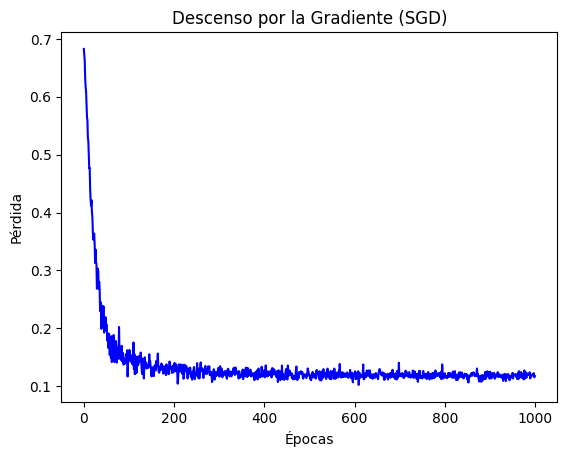

In [ ]:
model.eval()
with torch.no_grad():
    y_test_pred = model(X_test)
    clases = (y_test_pred > 0.5).float()
    
    aciertos = (clases == y_test).sum().item()
    precision = aciertos / len(y_test)

print("\n" + "="*40)
print(f"PRECISIÓN FINAL (SGD): {precision * 100:.2f}%")
print(f"ERROR MÍNIMO LOGRADO: {historial_loss[-1]:.6f}")
print("="*40)

plt.plot(historial_loss, color='blue')
plt.title("Descenso por la Gradiente (SGD)")
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.show()

Este conjunto de datos proviene de MIMIC, una base de datos clínica de acceso abierto muy importante en el área de la salud. El objetivo específico de este notebook es analizar los registros de ingresos hospitalarios para predecir un resultado crítico: si el paciente fallecerá o sobrevivirá durante su estancia en el hospital.
La variable objetivo principal es entrenar un modelo que pueda predecir la probabilidad de fallecimiento de un paciente en el hospital (hospital_expire_flag).
En mi fase de preparación, realicé una limpieza profunda que dividí en tres pasos clave:

Selección de variables y eliminación de ruido: Empecé aplicando lo que llamo un 'recorte de cirugía'. El dataset original tenía 19 columnas, pero decidí eliminar 16 de ellas (como row_id, subject_id y todas las fechas de ingreso o salida). Me quedé únicamente con tres variables: el tipo de admisión, la etnia y el tipo de seguro médico. Hice esto porque los IDs son solo números administrativos que no aportan valor médico, y las fechas podrían causar 'fuga de datos' (hacer trampa), ya que si el modelo ve una fecha de defunción, adivinaría el resultado sin aprender realmente los patrones de los pacientes.

Codificación numérica (Factorize): Como las tres columnas que seleccioné contienen texto (por ejemplo, 'EMERGENCY' o 'Medicare'), mi modelo no las podría procesar directamente. Para solucionar esto, utilicé la función factorize de Pandas para convertir cada categoría en un número. También generé un diccionario de mapeo para mantener el registro de qué significa cada número (por ejemplo, saber que el 0 representa una emergencia).

Normalización y Bias: Finalmente, convertí mis datos en matrices de NumPy y apliqué una Normalización Z-score. Esto es fundamental para que todas mis variables estén en la misma escala y el algoritmo de entrenamiento no se desestabilice. También añadí una columna de unos (Bias) a mi matriz de entrada para que el modelo pueda calcular correctamente el intercepto de la función logística.

Lo que se hizo es un modelo de clasificación binaria porque predice una categoría: si el paciente vive (0) o fallece (1).
Usa funciones como sigmoide para dar probabilidades entre 0 y 1, BCE para medir el error y un umbral (0.5) para decidir la clase final.

minimiza el erro y maximiza la presision